In [1]:
import os
import pickle
import numpy as np
from utils.load_preprocess import load_preprocess
from utils.train_evaluate import to_labels, bayesian_optimization
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score, f1_score, precision_recall_curve
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from xgboost import XGBClassifier

from bayes_opt import BayesianOptimization

import shap

import warnings
warnings.filterwarnings("ignore")

# Initialize rng
rng = np.random.default_rng(2022)

# # Genes
# selecting top 100 genes gives 81 from feature selection using stability
# selecting top 500 genes gives 4111 from feature selection using stability
n_genes = 100 # This is now deprecated

# Dataset filename options: 
# 'aak81Dataset_cpmdat.csv'  - 81 out of top 100 genes from feature selection using stability
# 'dge_05.csv' - differential gene expression, genes with p < 0.05
# 'dge_all.csv' - differential gene expression, all genes
# 'overlap_81_dge.csv' - overlap of dge with 81 genes from feature selection
dataset_filename = "xdec_latent_embedding.csv"

In [2]:
X = load_preprocess(dataset_filename, as_df=True)
y = X['class'].to_numpy()
X.drop(['class'], axis=1, inplace=True)

# DEPRECATED:
# neg_pos_ratio = np.count_nonzero(y == 0)/np.count_nonzero(y==1)
# neg_pos_ratio

In [3]:
# # times to run bootstrap
n_bootstrap = 100

# # of hyperparameter combinations to try in random search
n_iter = 100

Bootstrap iteration # 1 out of 100
Bootstrap iteration # 2 out of 100
Bootstrap iteration # 3 out of 100
Bootstrap iteration # 4 out of 100
Bootstrap iteration # 5 out of 100
Bootstrap iteration # 6 out of 100
Bootstrap iteration # 7 out of 100
Bootstrap iteration # 8 out of 100
Bootstrap iteration # 9 out of 100
Bootstrap iteration # 10 out of 100
Bootstrap iteration # 11 out of 100
Bootstrap iteration # 12 out of 100
Bootstrap iteration # 13 out of 100
Bootstrap iteration # 14 out of 100
Bootstrap iteration # 15 out of 100
Bootstrap iteration # 16 out of 100
Bootstrap iteration # 17 out of 100
Bootstrap iteration # 18 out of 100
Bootstrap iteration # 19 out of 100
Bootstrap iteration # 20 out of 100
Bootstrap iteration # 21 out of 100
Bootstrap iteration # 22 out of 100
Bootstrap iteration # 23 out of 100
Bootstrap iteration # 24 out of 100
Bootstrap iteration # 25 out of 100
Bootstrap iteration # 26 out of 100
Bootstrap iteration # 27 out of 100
Bootstrap iteration # 28 out of 100
B

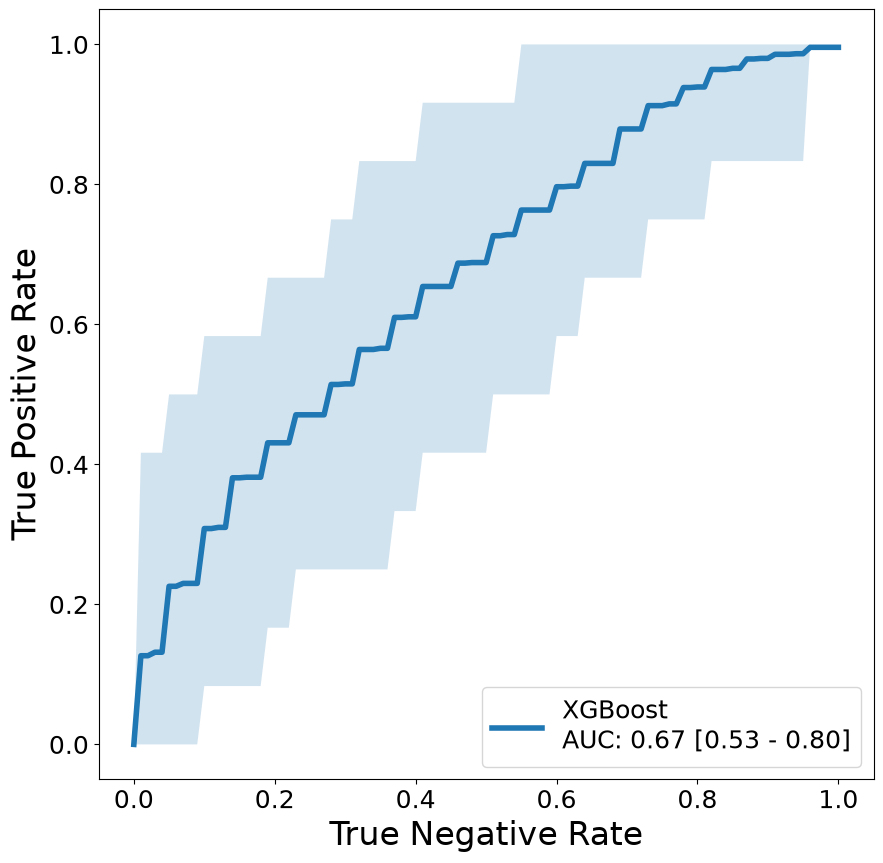

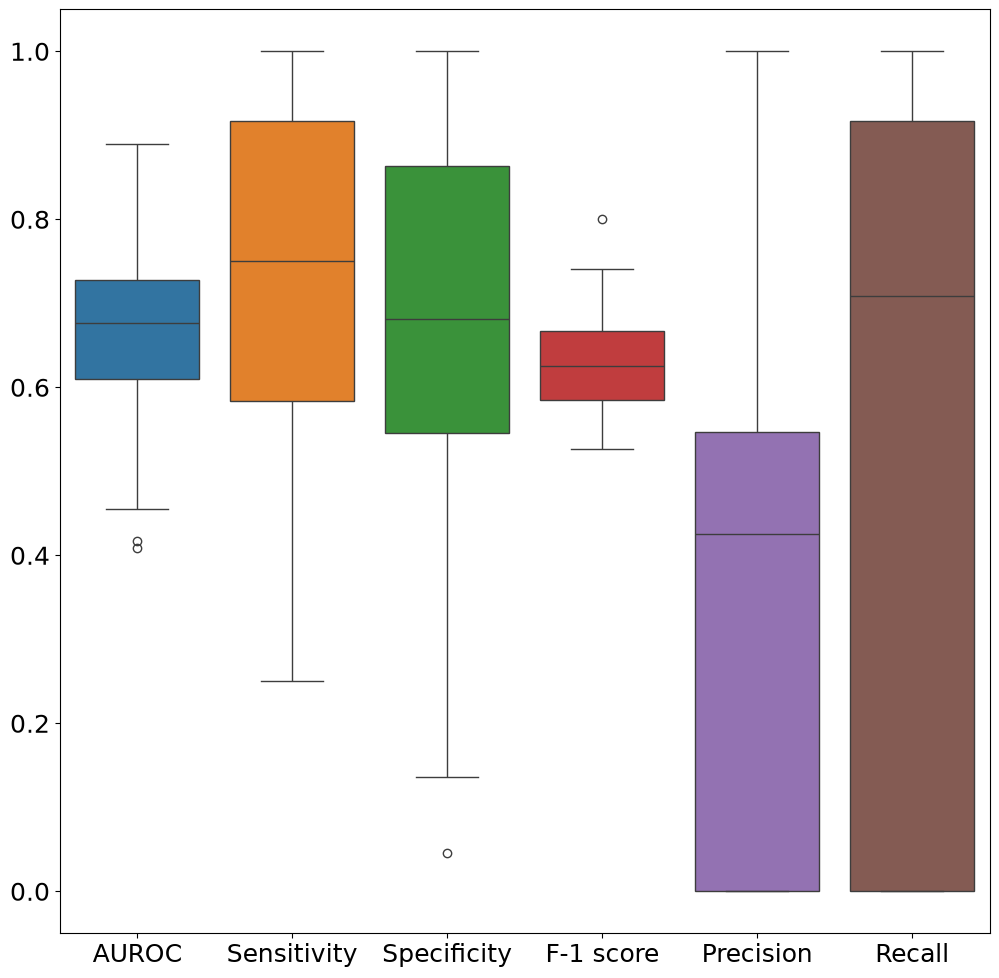

In [4]:
# Run Bayesian hyperparameter tuning
results_df, best_model_yet, shap_df = bayesian_optimization(X,
                                                            y,
                                                            n_bootstrap=n_bootstrap,
                                                            model_type='xgboost',
                                                            n_iter=n_iter,
                                                            verbose=1,
                                                            plot_roc=True,
                                                            save_roc_fig=True,
                                                            plot_boxplot=True,
                                                            save_boxplot=True,
                                                            save_results=True,
                                                            dataset_filename=dataset_filename,
                                                            path='results')

# Interpretation of all models using SHAP with CI

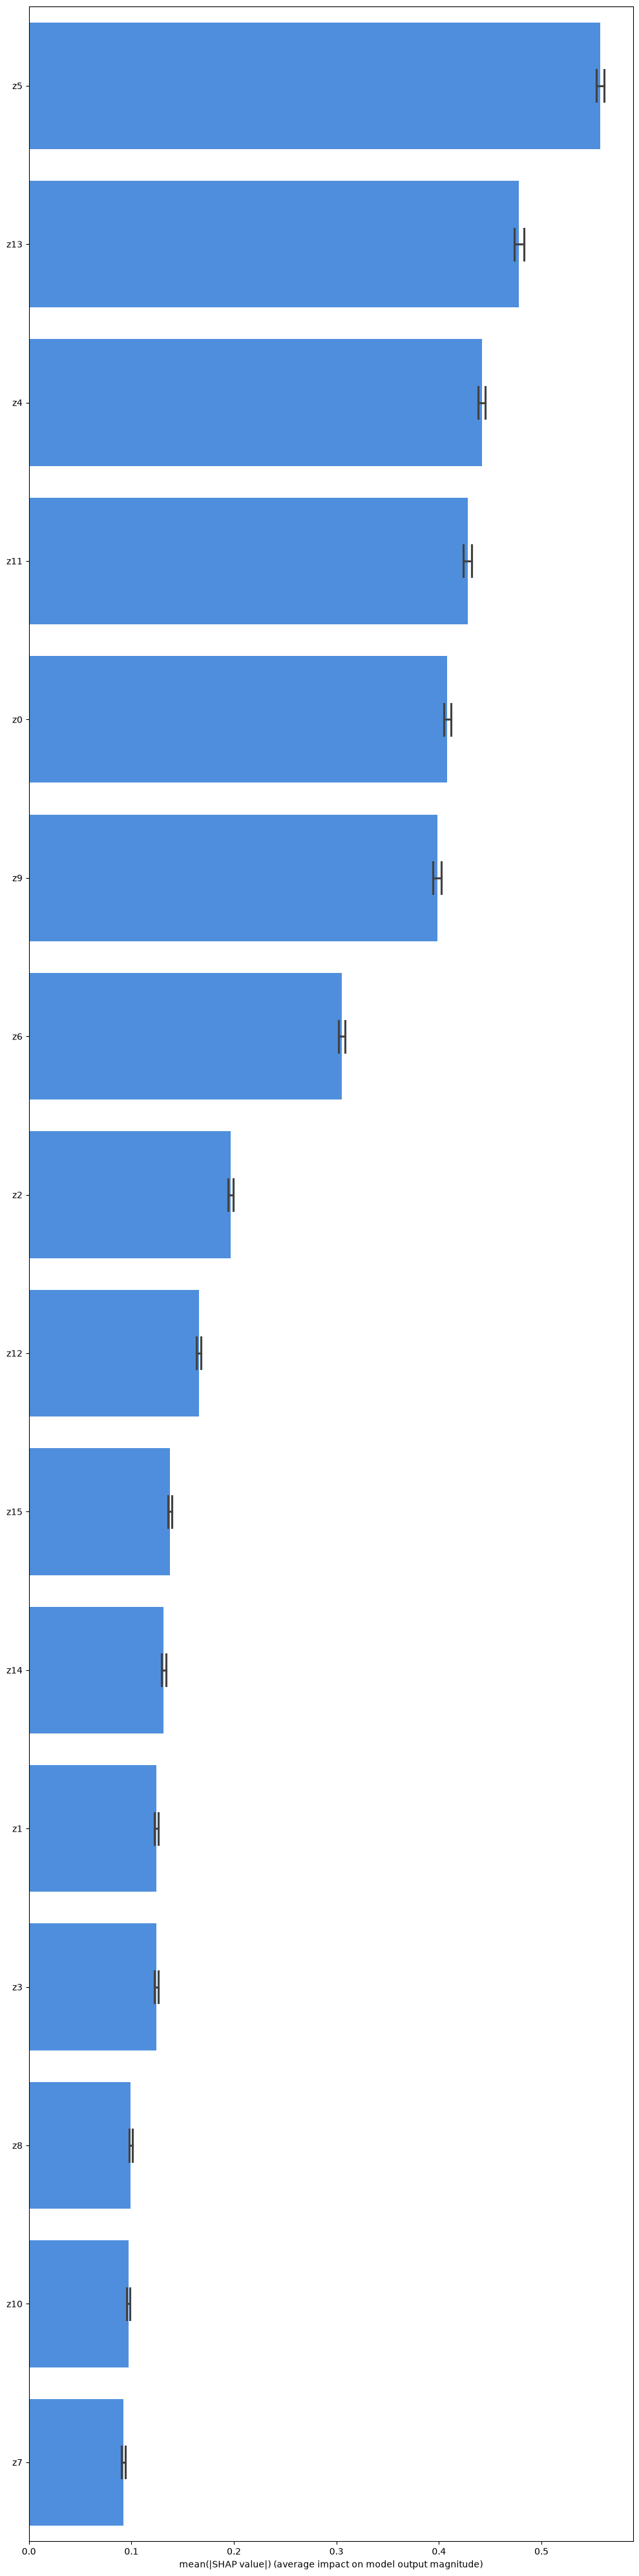

In [5]:
# # SHAP summary of absolute values
index_sort = shap_df.abs().mean().sort_values(ascending=False).index
shap_df_sorted = shap_df.abs()[index_sort]

f = plt.figure(figsize=(10,40))
ax = plt.gca()
barplot = sns.barplot(data=shap_df_sorted,
                      estimator=np.mean,
                      ci=90,
                      capsize=.2,
                      color='#388BF3',
                      orient='h',
                      ax=ax)
plt.xlabel('mean(|SHAP value|) (average impact on model output magnitude)')

f = plt.gcf()
f.tight_layout()
f.savefig(os.path.join('results', 'XGBoost_Bayesian_shap_summary_plot_CI_barplot_{}.pdf'.format(dataset_filename)))

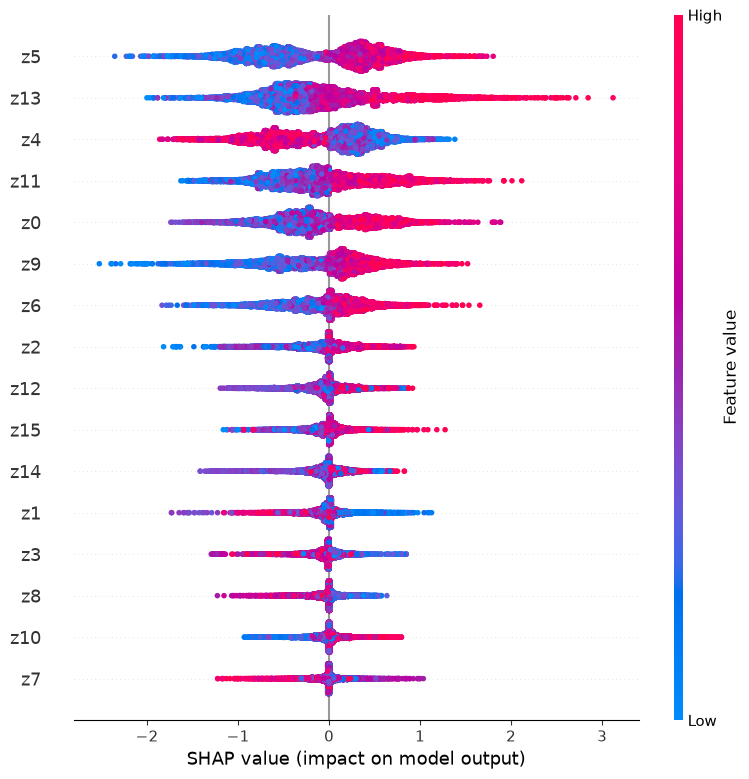

<Figure size 640x480 with 0 Axes>

In [6]:
# SHAP summary with swarm plot
dummy_df = pd.DataFrame(columns=X.columns)
for i in range(n_bootstrap):
    dummy_df = pd.concat([dummy_df, X], ignore_index=True)
shap.summary_plot(shap_df.to_numpy().astype('float64'), dummy_df.astype('float64'))
f = plt.gcf()
f.tight_layout()
f.savefig(os.path.join('results', 'XGBoost_Bayesian_shap_summary_plot_CI_{}.pdf'.format(dataset_filename)))

# Interpretation

In [7]:
# import xgboost
# import shap

In [8]:
# # importance by weight
# _, ax_weight = plt.subplots(figsize=(12,12))
# xgboost.plot_importance(best_model_yet, ax=ax_weight)
# plt.title("xgboost.plot_importance(model)");

In [9]:
# # importance by gain
# _, ax_gain = plt.subplots(figsize=(12,12))
# xgboost.plot_importance(best_model_yet, importance_type='gain', ax=ax_gain)
# plt.title("xgboost.plot_importance(model)");

In [10]:
# # importance by cover
# _, ax_cover = plt.subplots(figsize=(12,12))
# xgboost.plot_importance(best_model_yet, importance_type='cover', ax=ax_cover)
# plt.title("xgboost.plot_importance(model)");

## The results are not consistent for xgboost plot_importance

# Using SHAP

In [11]:
# explainer = shap.TreeExplainer(best_model_yet)
# shap_values = explainer.shap_values(X)

In [12]:
# shap_values

In [13]:
# shap.initjs() 
# shap.force_plot(explainer.expected_value, shap_values[0,:], X.iloc[0,:])

## The above looks similar to the weight method in xgboost plot_importance

In [14]:
# shap.force_plot(explainer.expected_value, shap_values, X)

In [15]:
# # Bar chart of mean importance
# shap.summary_plot(shap_values, X, plot_type="bar")

In [16]:
# Summary plot
# shap.summary_plot(shap_values, X, max_display=20)

In [17]:
# # Save SHAP summary
# shap.summary_plot(shap_values, X, max_display=81, show=False)
# f = plt.gcf()
# ax = plt.gca()
# ax.set_xticks(np.linspace(-2, 2, 41, endpoint=True))
# f.set_size_inches(25, 25)
# f.tight_layout()
# f.savefig(os.path.join('results', 'XGBoost_Bayesian_shap_summary_plot_bestModel_{}.pdf'.format(dataset_filename)))

In [18]:
# # Save shap_values and X so that we can plot later
# shap_dict = {'X': X,
#              'shap_values': shap_values}
# with open(os.path.join('results', 'XGBoost_Bayesian_shap_bestModel.pkl'), 'wb') as f:
#     pickle.dump(shap_dict, f)